Citation / References:
1. https://www.youtube.com/watch?v=iCwMQJnKk2c&list=PL-wATfeyAMNqIee7cH3q1bh4QJFAaeNv0
2. https://github.com/musikalkemist/AudioSignalProcessingForML/tree/master

# Audio Feature Extraction & Analysis
## Index
1. [Imports and Setup](#1.-Imports-and-Setup)
2. [Audio Loading and Basic Information](#2.-Audio-Loading-and-Basic-Information)
3. [Waveform Visualization](#3.-Waveform-Visualization)
4. [Amplitude Envelope](#4.-Amplitude-Envelope)
5. [Root Mean Square (RMS) Energy](#5.-Root-Mean-Square-(RMS)-Energy)
6. [Zero Crossing Rate (ZCR)](#6.-Zero-Crossing-Rate-(ZCR))
7. [Fast Fourier Transform (FFT)](#7.-Fast-Fourier-Transform-(FFT))
8. [Spectrogram Visualization](#8.-Spectrogram-Visualization)
9. [Mel Spectrogram](#9.-Mel-Spectrogram)
10. [Mel-Frequency Cepstral Coefficients (MFCCs)](#10.-Mel-Frequency-Cepstral-Coefficients-(MFCCs))

## 1. Imports and Setup

In [1]:
import librosa
import librosa.display
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)


## 2. Audio Loading and Basic Information

In [2]:
wav = 'wave.wav'
ipd.Audio(wav)


### 2.1 Signal Loading

In [3]:
wav_array, sr = librosa.load(wav)
print(f'Signal shape: {wav_array.shape}')
print(f'Sample rate: {sr} Hz')


Signal shape: (88200,)
Sample rate: 22050 Hz


## 3. Waveform Visualization

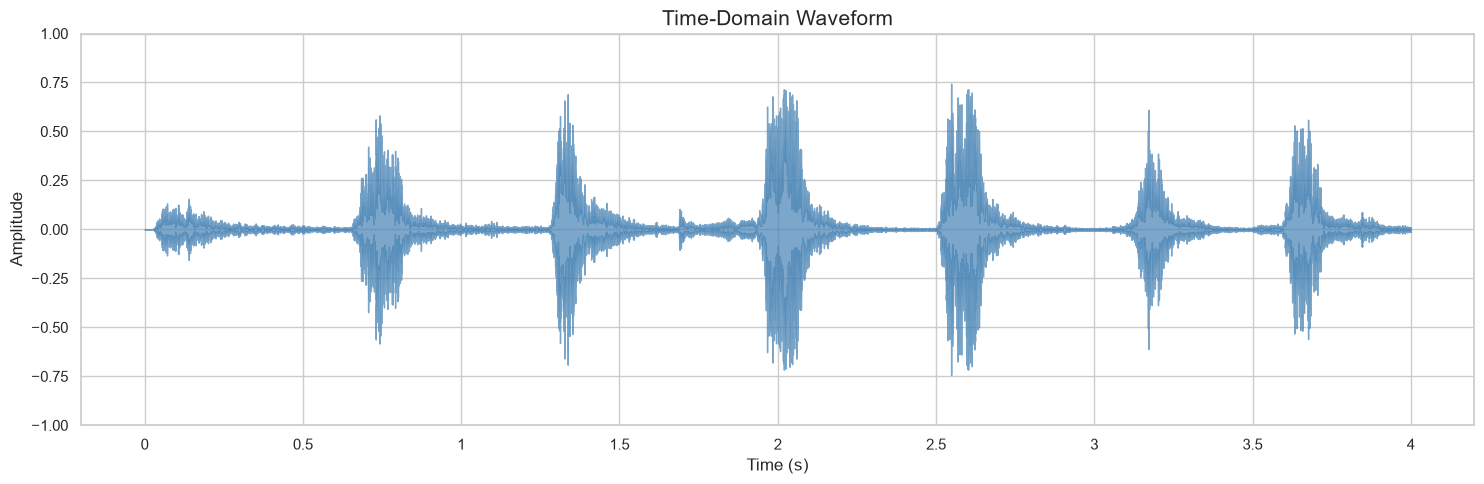

In [4]:
plt.figure(figsize=(15, 5))
librosa.display.waveshow(wav_array, alpha=0.7, color='steelblue')
plt.title('Time-Domain Waveform', fontsize=15)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.ylim((-1, 1))
plt.tight_layout()
plt.show()


## 4. Amplitude Envelope

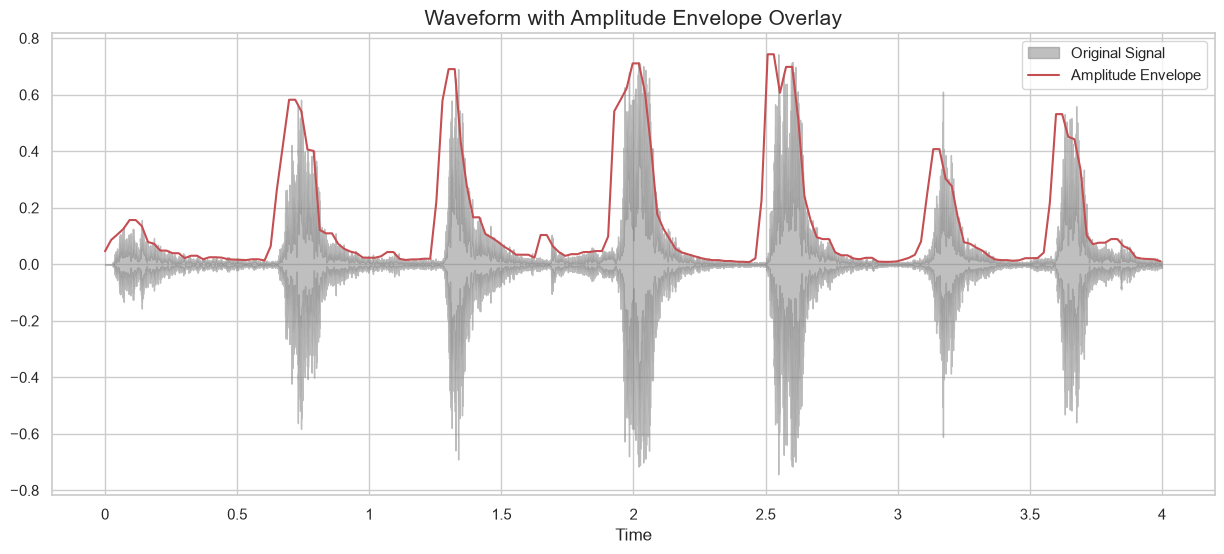

In [5]:
FRAME_SIZE = 1024
HOP_LENGTH = 512
def amplitude_envelope(signal, frame_size, hop_length):
    return np.array([max(signal[i : i + frame_size]) for i in range(0, signal.size, hop_length)])
ae_wav = amplitude_envelope(wav_array, FRAME_SIZE, HOP_LENGTH)
frames = range(0, ae_wav.size)
t = librosa.frames_to_time(frames, hop_length=HOP_LENGTH)
plt.figure(figsize=(15, 6))
librosa.display.waveshow(wav_array, alpha=0.5, color='gray', label='Original Signal')
plt.plot(t, ae_wav, color='r', linewidth=1.5, label='Amplitude Envelope')
plt.title('Waveform with Amplitude Envelope Overlay', fontsize=15)
plt.legend()
plt.show()


## 5. Root Mean Square (RMS) Energy

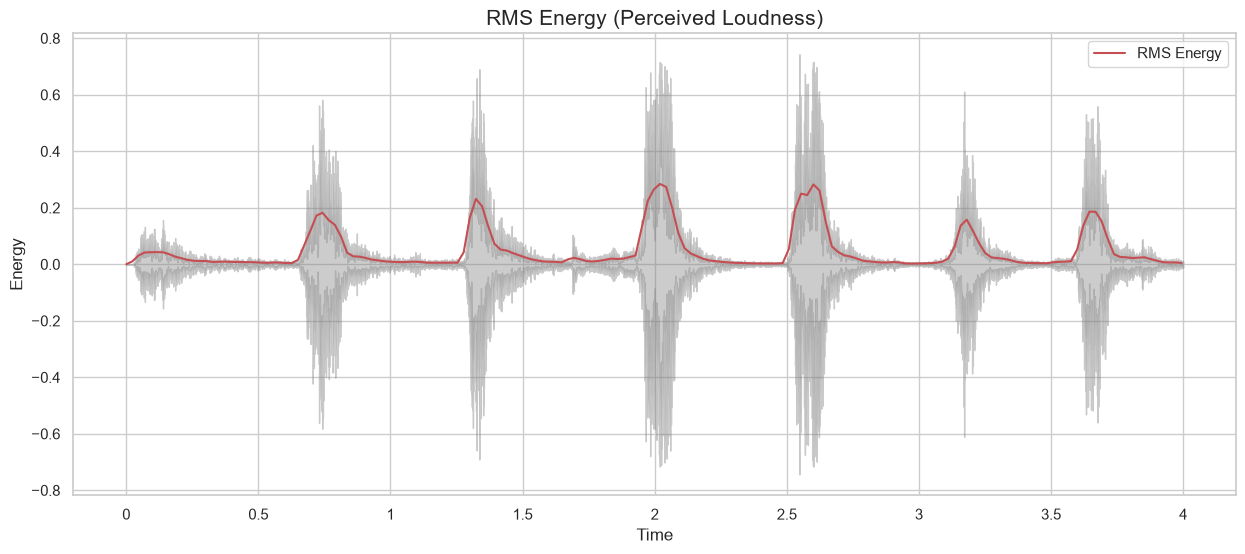

In [6]:
rms_wav = librosa.feature.rms(y=wav_array, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)[0]
t_rms = librosa.frames_to_time(range(len(rms_wav)), hop_length=HOP_LENGTH)
plt.figure(figsize=(15, 6))
librosa.display.waveshow(wav_array, alpha=0.4, color='gray')
plt.plot(t_rms, rms_wav, color='r', label='RMS Energy')
plt.title('RMS Energy (Perceived Loudness)', fontsize=15)
plt.ylabel('Energy')
plt.legend()
plt.show()


## 6. Zero Crossing Rate (ZCR)

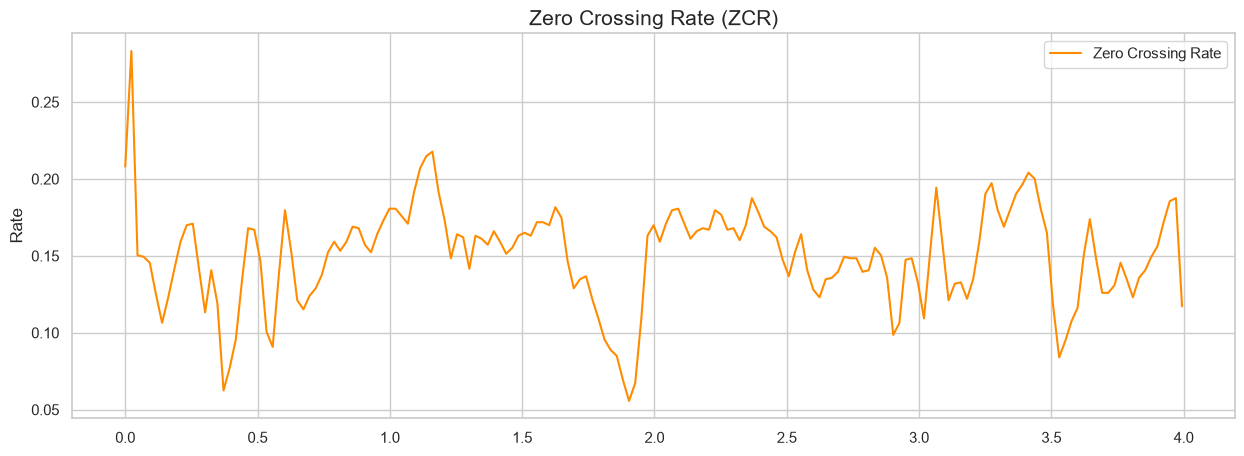

In [7]:
zcr = librosa.feature.zero_crossing_rate(y=wav_array, frame_length=FRAME_SIZE, hop_length=HOP_LENGTH)[0]
plt.figure(figsize=(15, 5))
plt.plot(t_rms, zcr, color='darkorange', label='Zero Crossing Rate')
plt.title('Zero Crossing Rate (ZCR)', fontsize=15)
plt.ylabel('Rate')
plt.legend()
plt.show()


## 7. Fast Fourier Transform (FFT)

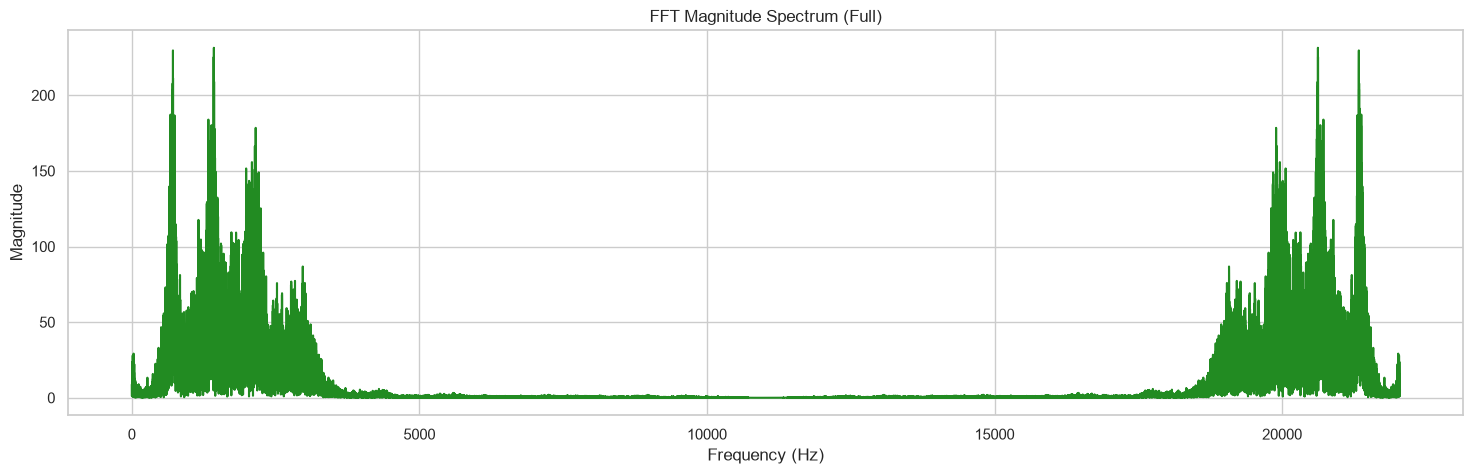

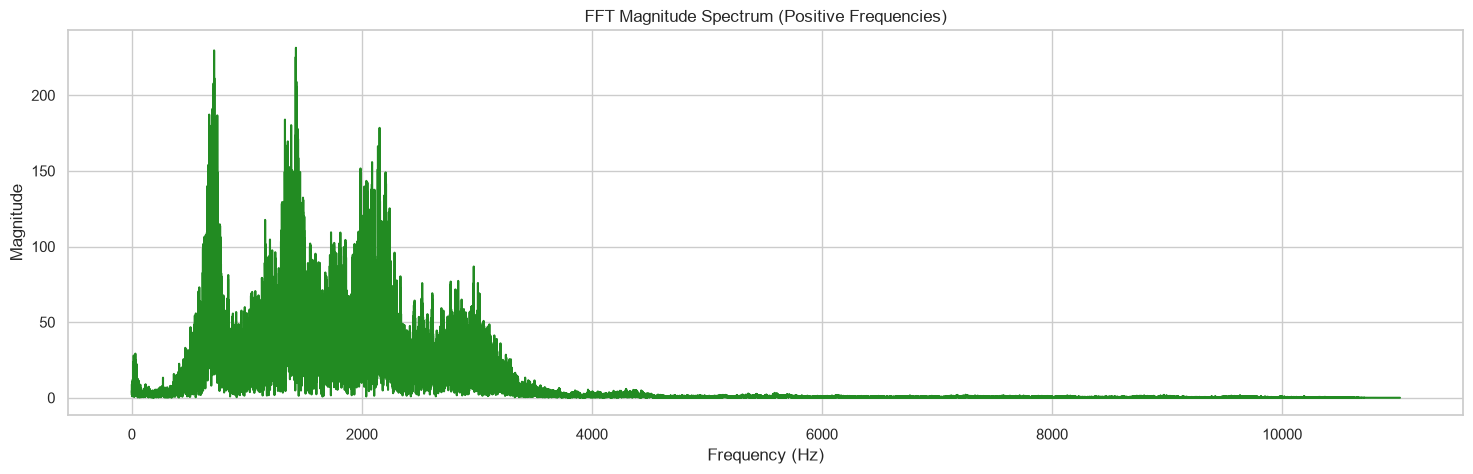

In [12]:
def plot_magnitude_spectrum(signal, title, sr, f_ratio=1.0):
    """Calculates FFT, extracts magnitude spectrum, and plots frequency bins.

    f_ratio:
        1.0 -> plot the full FFT (0 to Fs)
        0.5 -> plot only the positive frequencies (0 to Fs/2)
    """
    # Compute FFT
    ft = np.fft.fft(signal)
    magnitude_spectrum = np.abs(ft)

    # Frequency axis
    frequency = np.linspace(0, sr, len(magnitude_spectrum))

    # Number of frequency bins to display
    num_frequency_bins = int(len(frequency) * f_ratio)

    plt.figure(figsize=(18, 5))
    plt.plot(
        frequency[:num_frequency_bins],
        magnitude_spectrum[:num_frequency_bins],
        color="forestgreen"
    )

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title(title)
    plt.grid(True)
    plt.show()


# Full FFT (contains both positive and mirrored negative frequencies)
plot_magnitude_spectrum(
    wav_array,
    "FFT Magnitude Spectrum (Full)",
    sr,
    f_ratio=1.0
)

# Positive frequencies only (most commonly used)
plot_magnitude_spectrum(
    wav_array,
    "FFT Magnitude Spectrum (Positive Frequencies)",
    sr,
    f_ratio=0.5
)

## 8. Spectrogram Visualization

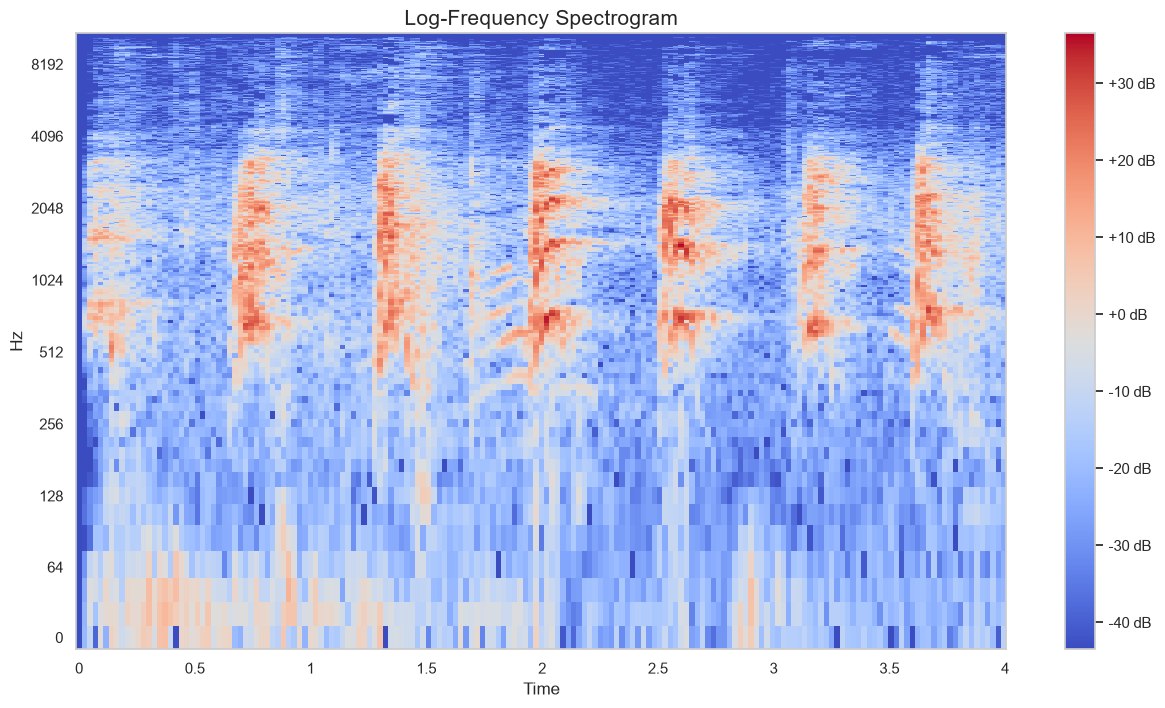

In [9]:
STFT = librosa.stft(wav_array, n_fft=FRAME_SIZE, hop_length=HOP_LENGTH)
spectrogram = np.abs(STFT)**2
log_spectrogram = librosa.power_to_db(spectrogram)
plt.figure(figsize=(15, 8))
img = librosa.display.specshow(log_spectrogram, sr=sr, hop_length=HOP_LENGTH, x_axis='time', y_axis='log')
plt.colorbar(img, format='%+2.0f dB')
plt.title('Log-Frequency Spectrogram', fontsize=15)
plt.show()


## 9. Mel Spectrogram

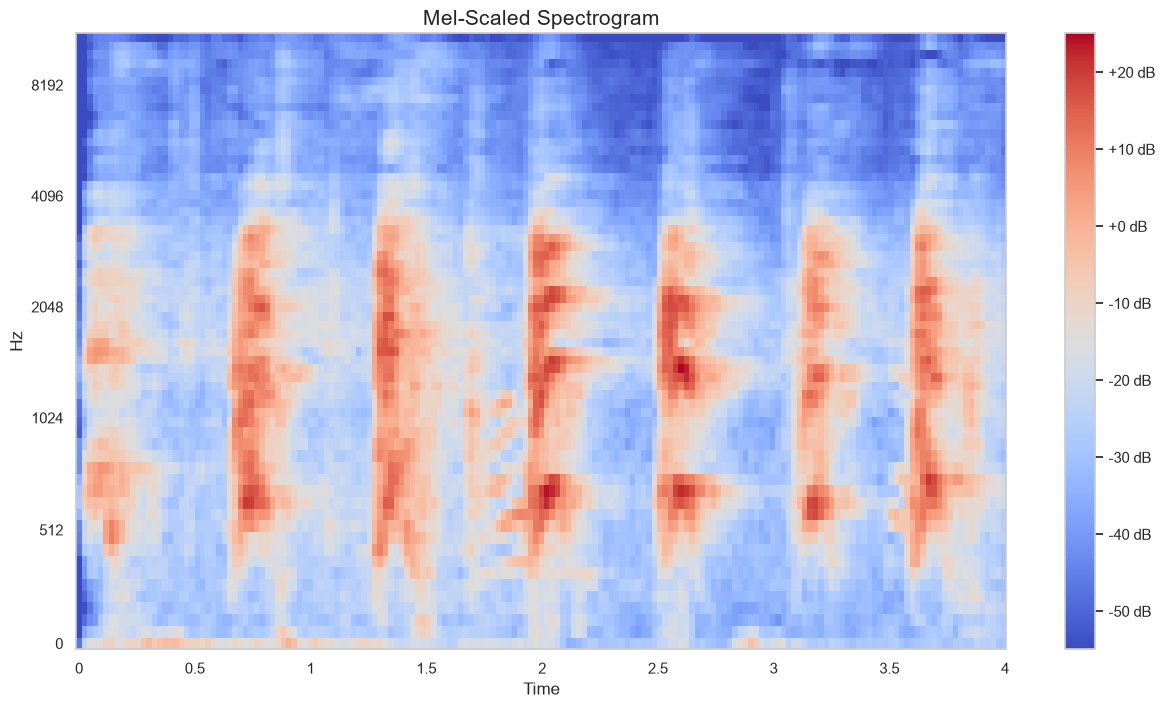

In [10]:
mel_spec = librosa.feature.melspectrogram(y=wav_array, sr=sr, n_mels=64)
log_mel_spec = librosa.power_to_db(mel_spec)
plt.figure(figsize=(15, 8))
img = librosa.display.specshow(log_mel_spec, x_axis='time', y_axis='mel', sr=sr)
plt.colorbar(img, format='%+2.0f dB')
plt.title('Mel-Scaled Spectrogram', fontsize=15)
plt.show()


## 10. Mel-Frequency Cepstral Coefficients (MFCCs)

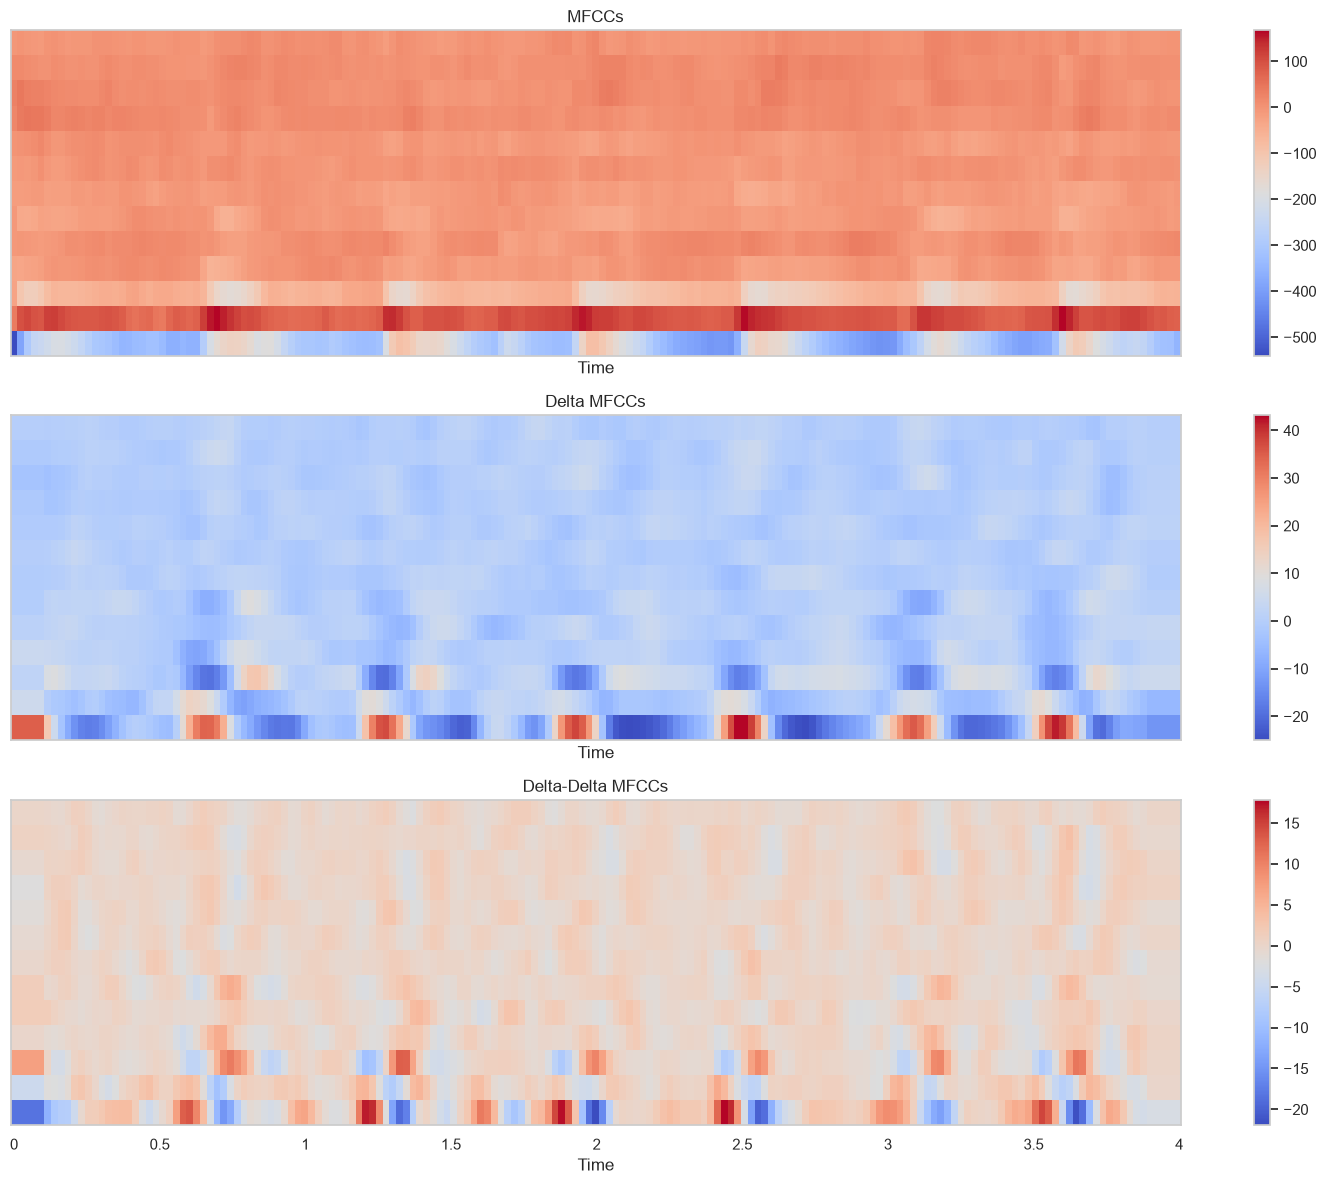

In [11]:
mfccs = librosa.feature.mfcc(y=wav_array, sr=sr, n_mfcc=13)
delta_mfccs = librosa.feature.delta(mfccs)
delta2_mfccs = librosa.feature.delta(mfccs, order=2)
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
for i, (data, title) in enumerate(zip([mfccs, delta_mfccs, delta2_mfccs], ['MFCCs', 'Delta MFCCs', 'Delta-Delta MFCCs'])):
    img = librosa.display.specshow(data, x_axis='time', sr=sr, ax=axes[i])
    axes[i].set_title(title)
    fig.colorbar(img, ax=axes[i])
plt.tight_layout()
plt.show()
